In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/Clean_Dataset (1).csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


### Data Preparation

In [ ]:
# Remove Unnamed: 0 column

df = df.drop(columns='Unnamed: 0')
df.head(2)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [ ]:
# Change Data Type

df['days_left'] = df['days_left'].astype('float')
df['price'] = df['price'].astype('float')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  float64
 10  price             300153 non-null  float64
dtypes: float64(3), object(8)
memory usage: 25.2+ MB


In [ ]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [ ]:
# Missing Values

df.isna().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [ ]:
#checking unique value in this data set
for col in df.columns:
    print(col, df[col].nunique())

airline 6
flight 1561
source_city 6
departure_time 6
stops 3
arrival_time 6
destination_city 6
class 2
duration 476
days_left 49
price 12157


### EDA

#### Univariate Analysis

In [ ]:
# Categorical Variables

cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')

In [ ]:
for col in cat_cols:
  print(f'No. of Unique values in {col}: ', df[col].nunique())
  print(f'Unique values in {col}: ', df[col].unique(), '\n')

No. of Unique values in airline:  6
Unique values in airline:  ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India'] 

No. of Unique values in flight:  1561
Unique values in flight:  ['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433'] 

No. of Unique values in source_city:  6
Unique values in source_city:  ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai'] 

No. of Unique values in departure_time:  6
Unique values in departure_time:  ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night'] 

No. of Unique values in stops:  3
Unique values in stops:  ['zero' 'one' 'two_or_more'] 

No. of Unique values in arrival_time:  6
Unique values in arrival_time:  ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night'] 

No. of Unique values in destination_city:  6
Unique values in destination_city:  ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi'] 

No. of Unique values in class:  2
Unique values in class:  ['Economy' 'B

In [ ]:
# from sklearn.preprocessing import StandardScaler

# # Separate features (X) and target (y)
# X = df.drop('price', axis=1)
# y = df['price']
# # Identify numerical columns for scaling (excluding one-hot encoded binary columns and 'days_left' if not already scaled)
# # We'll assume 'duration' and 'days_left' are the primary numerical features to scale
# numerical_cols = ['duration', 'days_left']

# # Initialize StandardScaler
# scaler = StandardScaler()

# # Apply scaling to numerical features
# X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# print("First 5 rows of scaled features (X):")
# display(X.head())

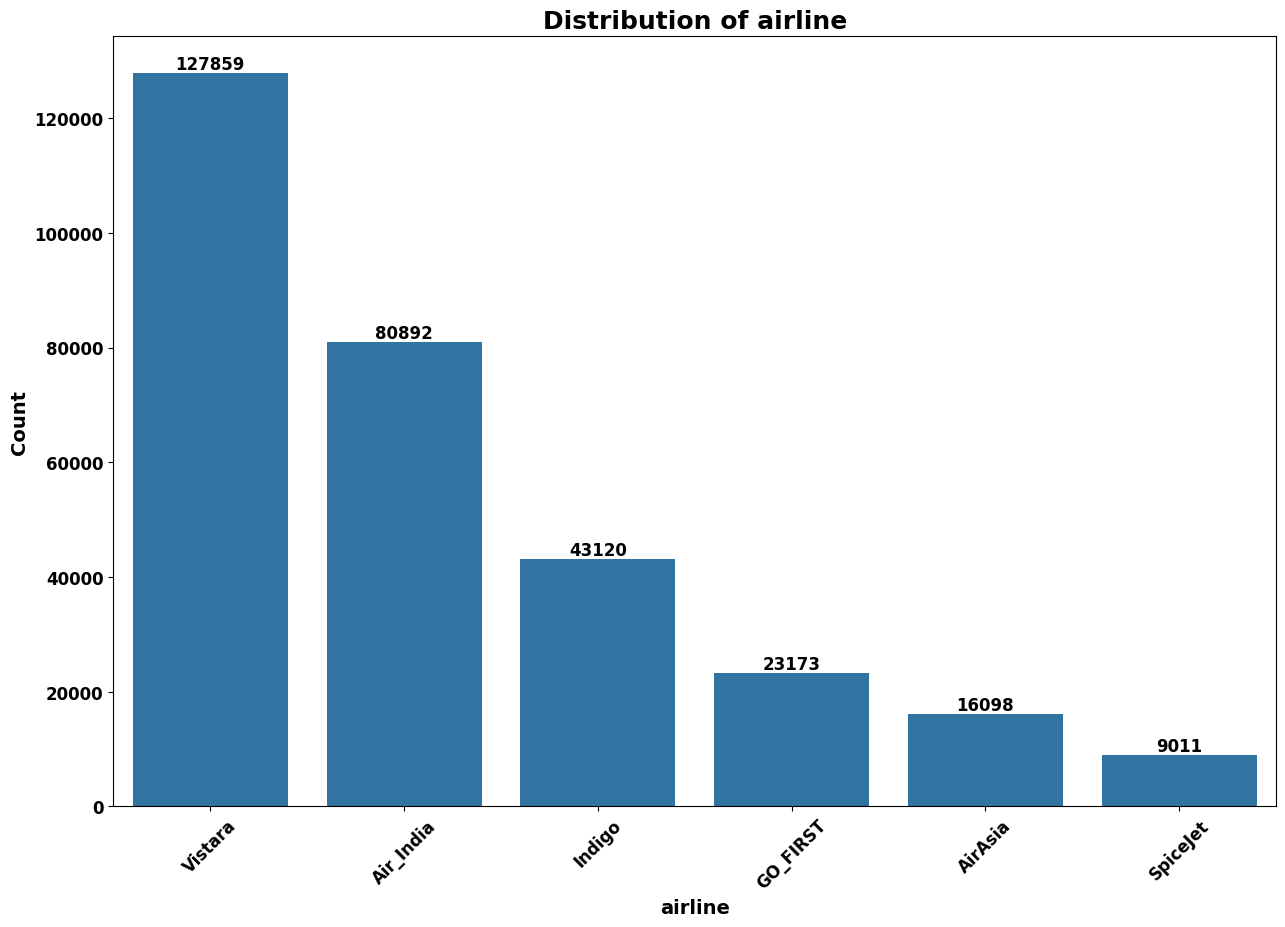

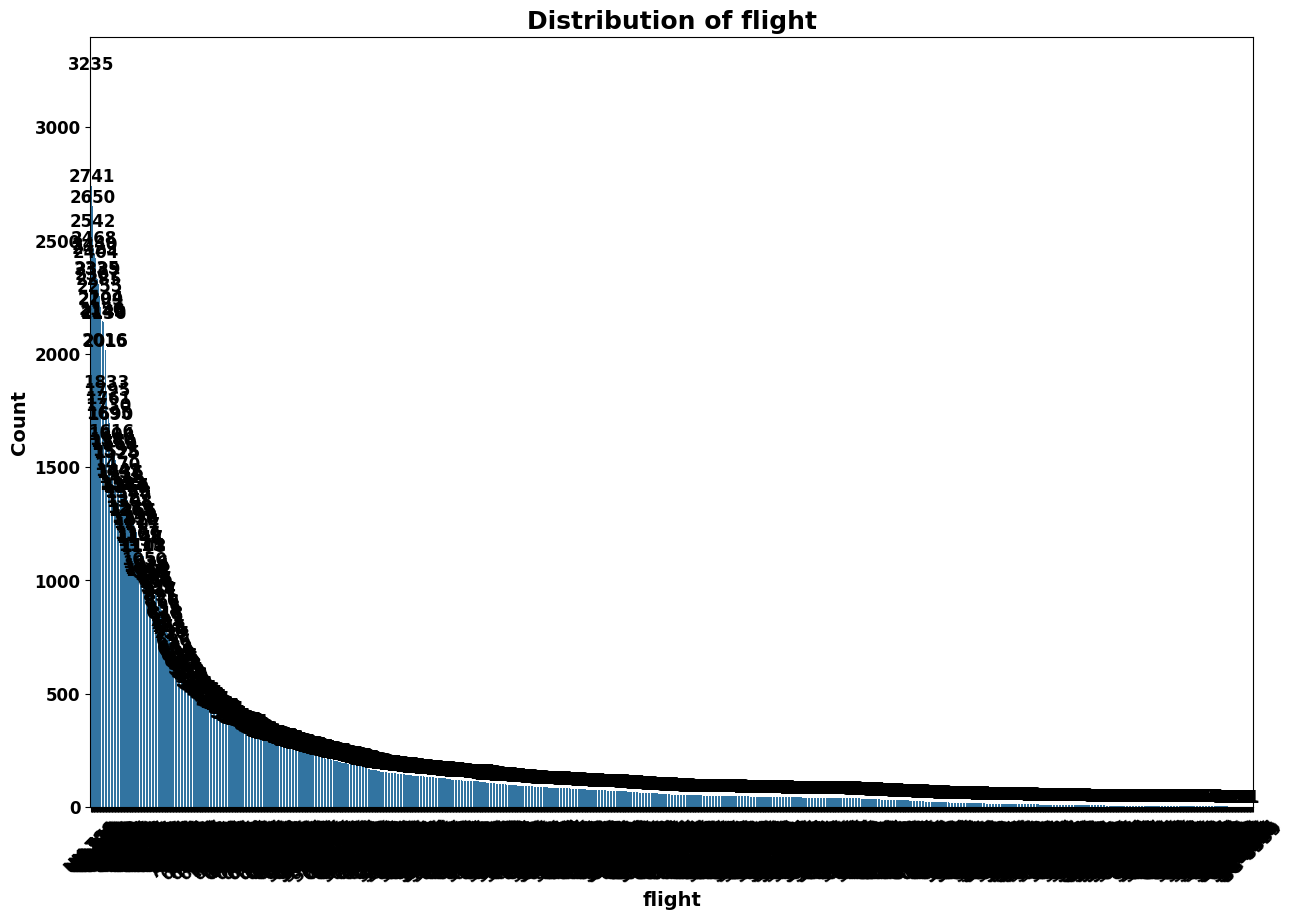

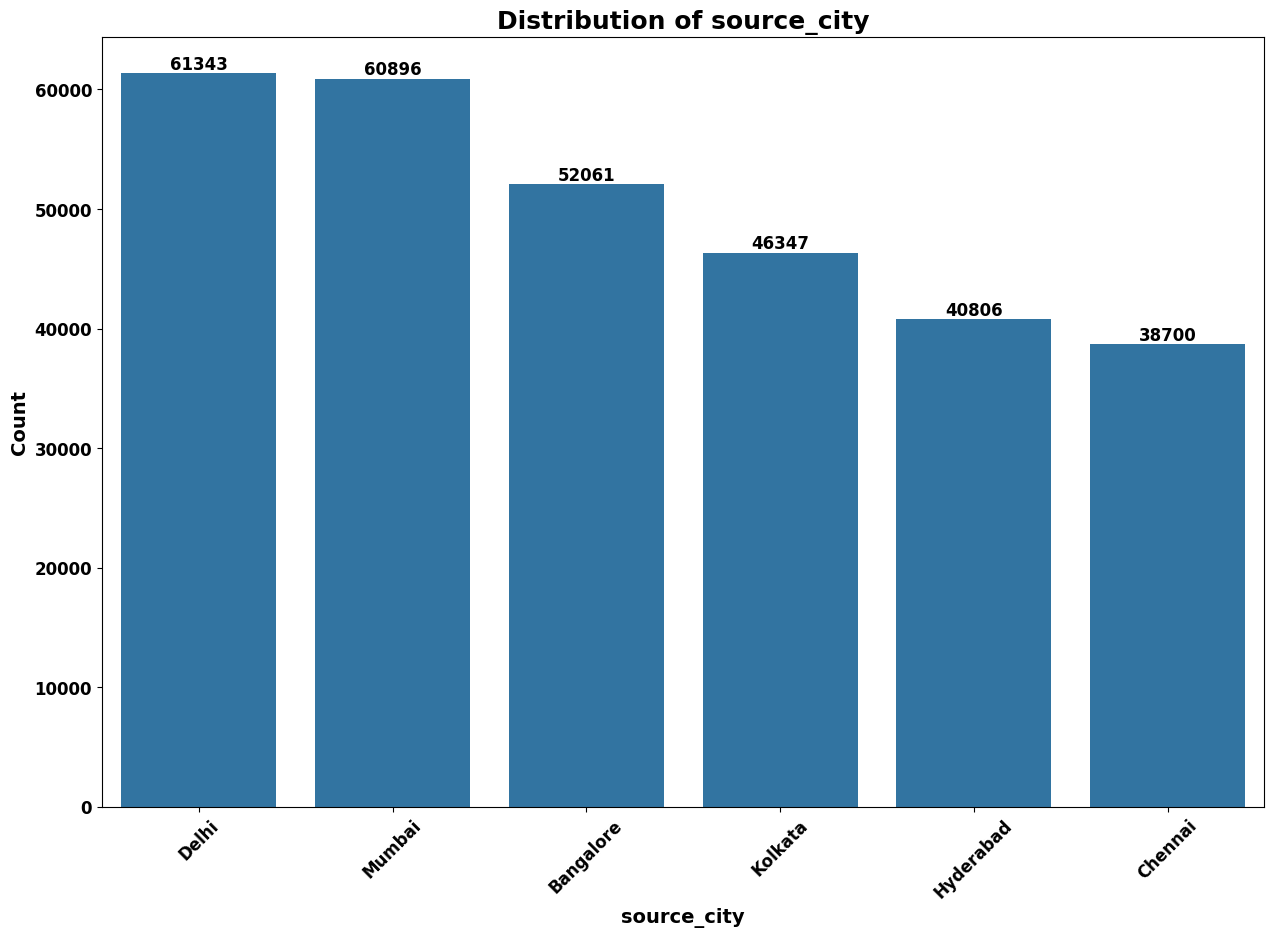

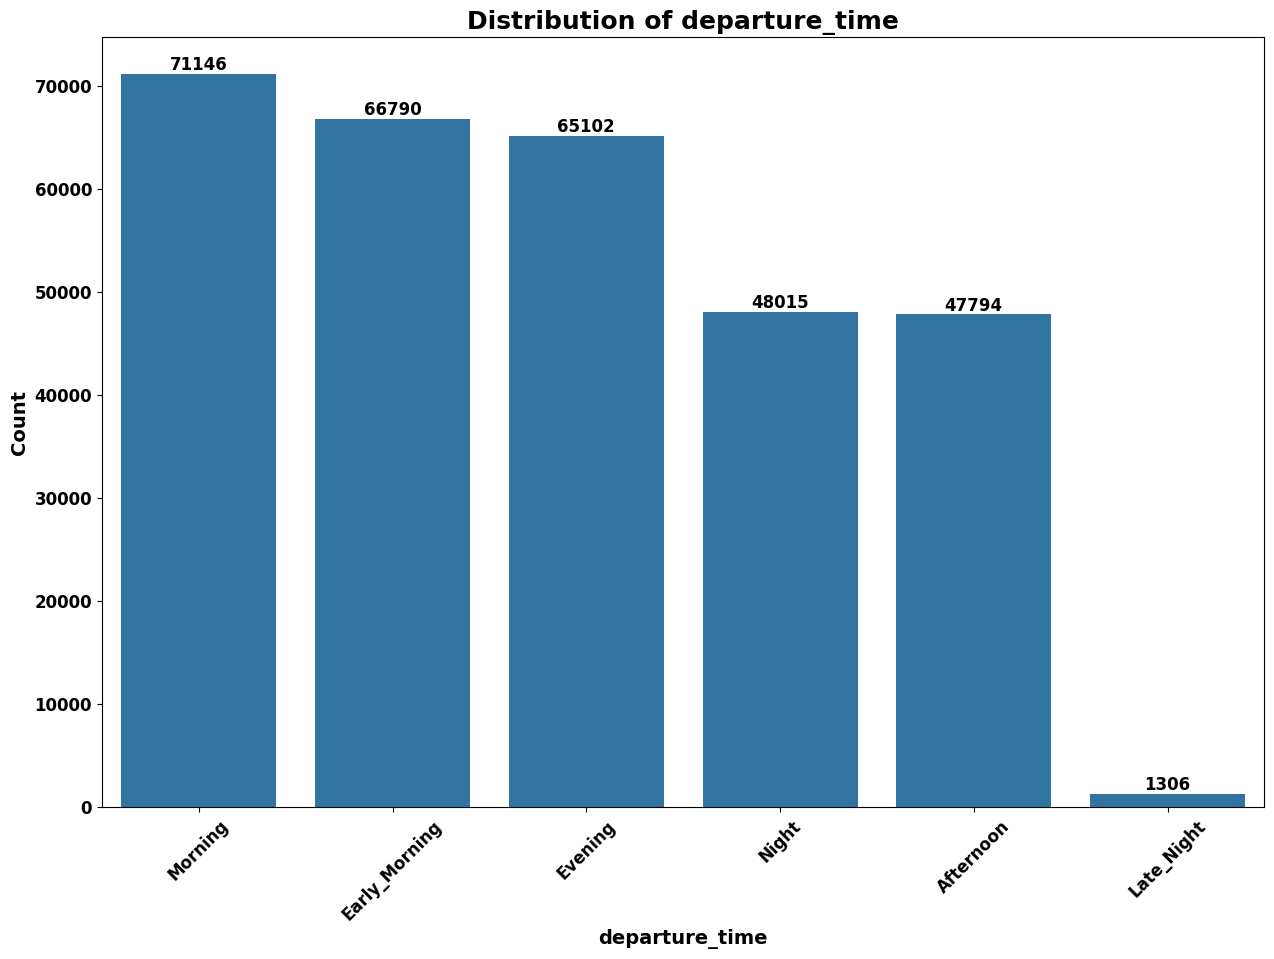

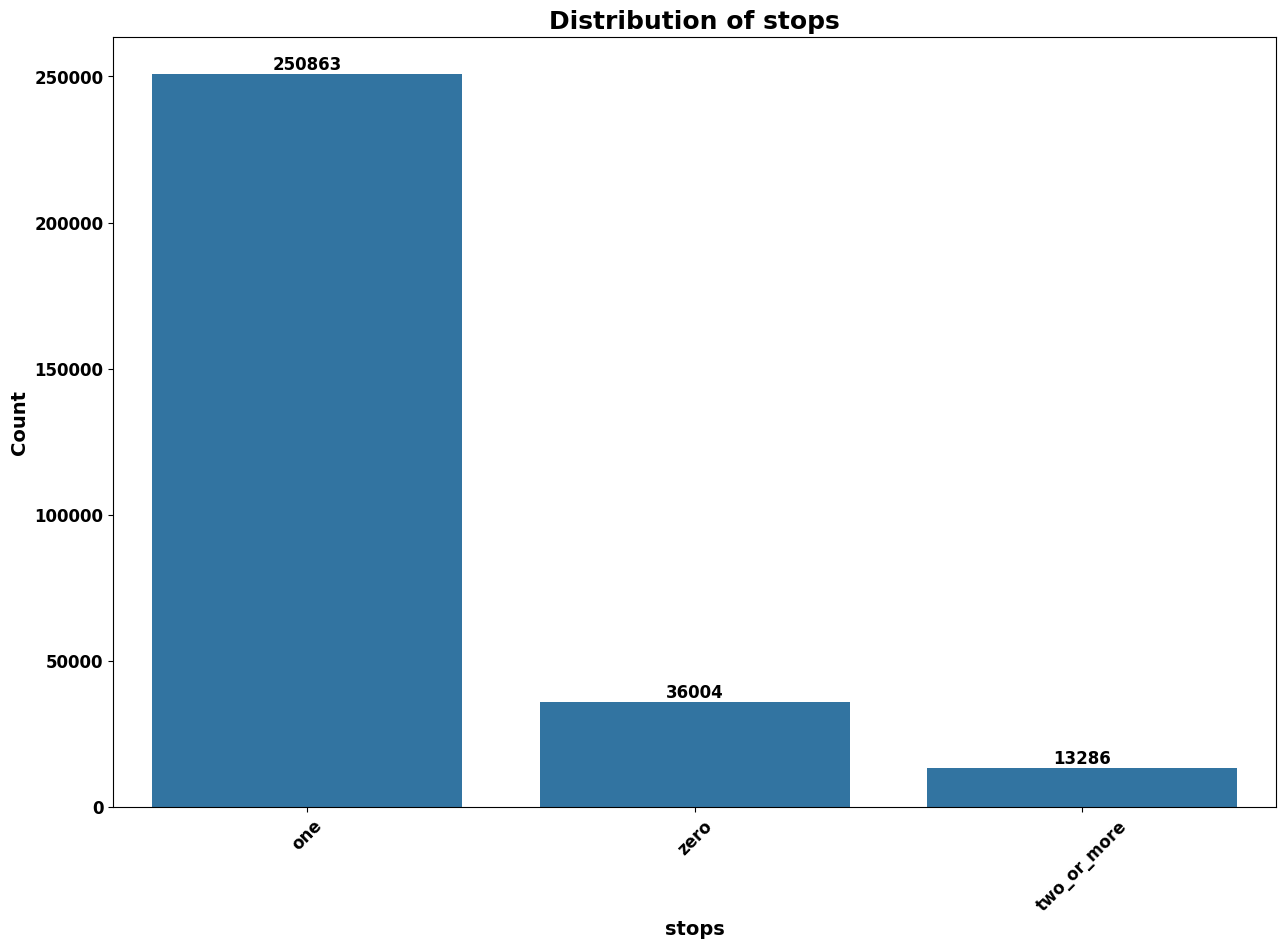

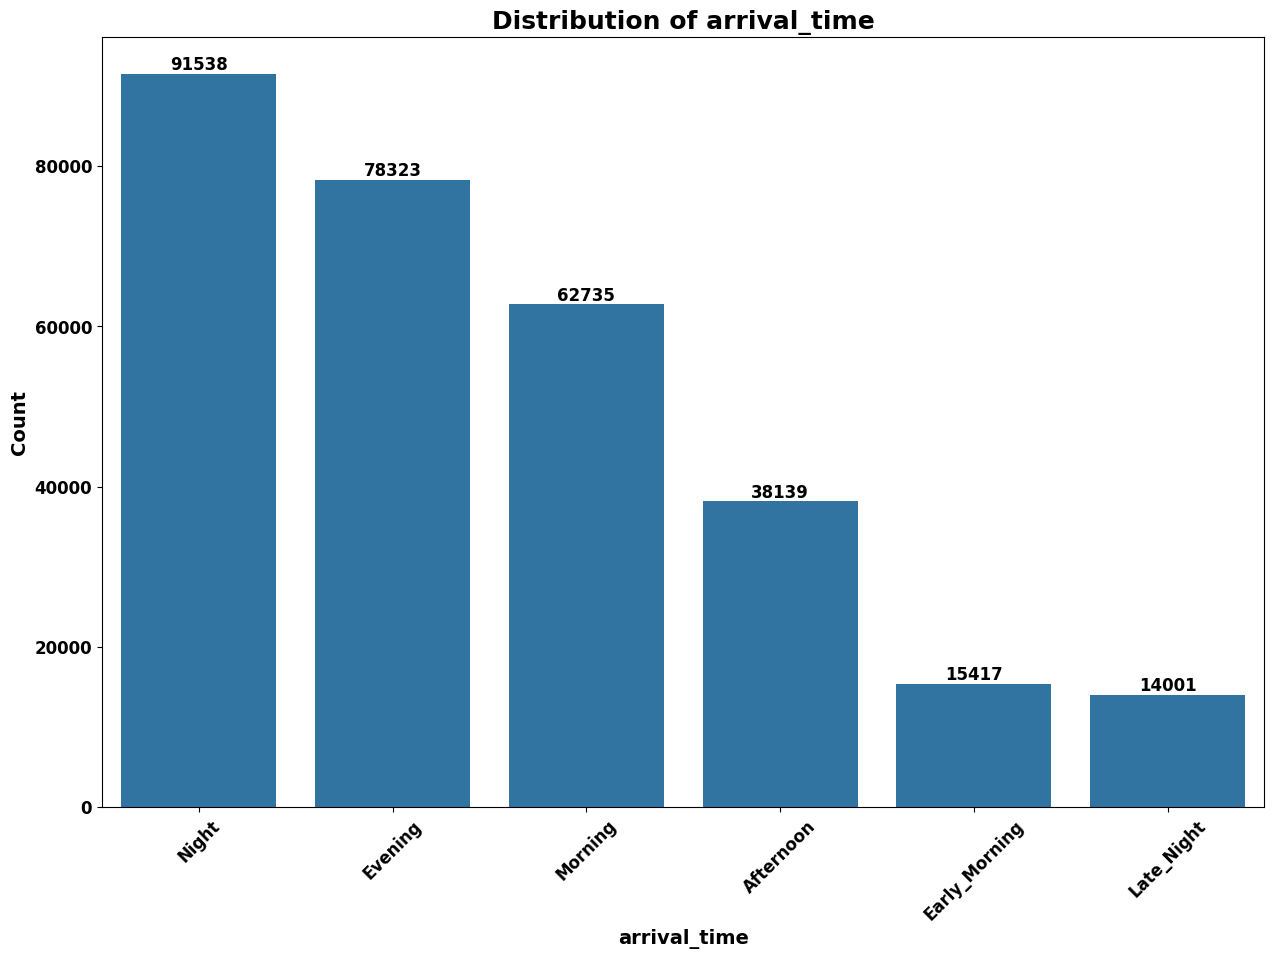

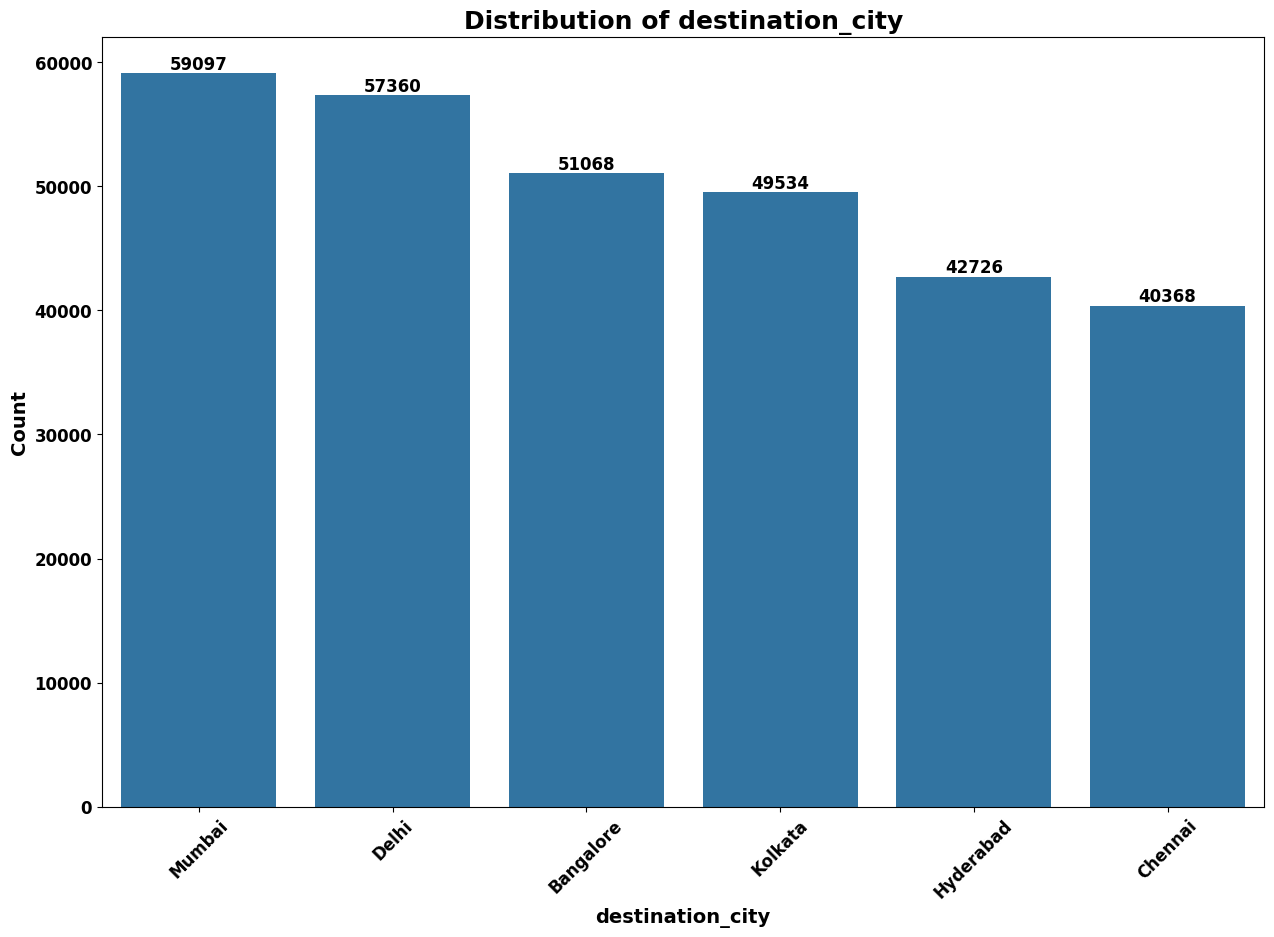

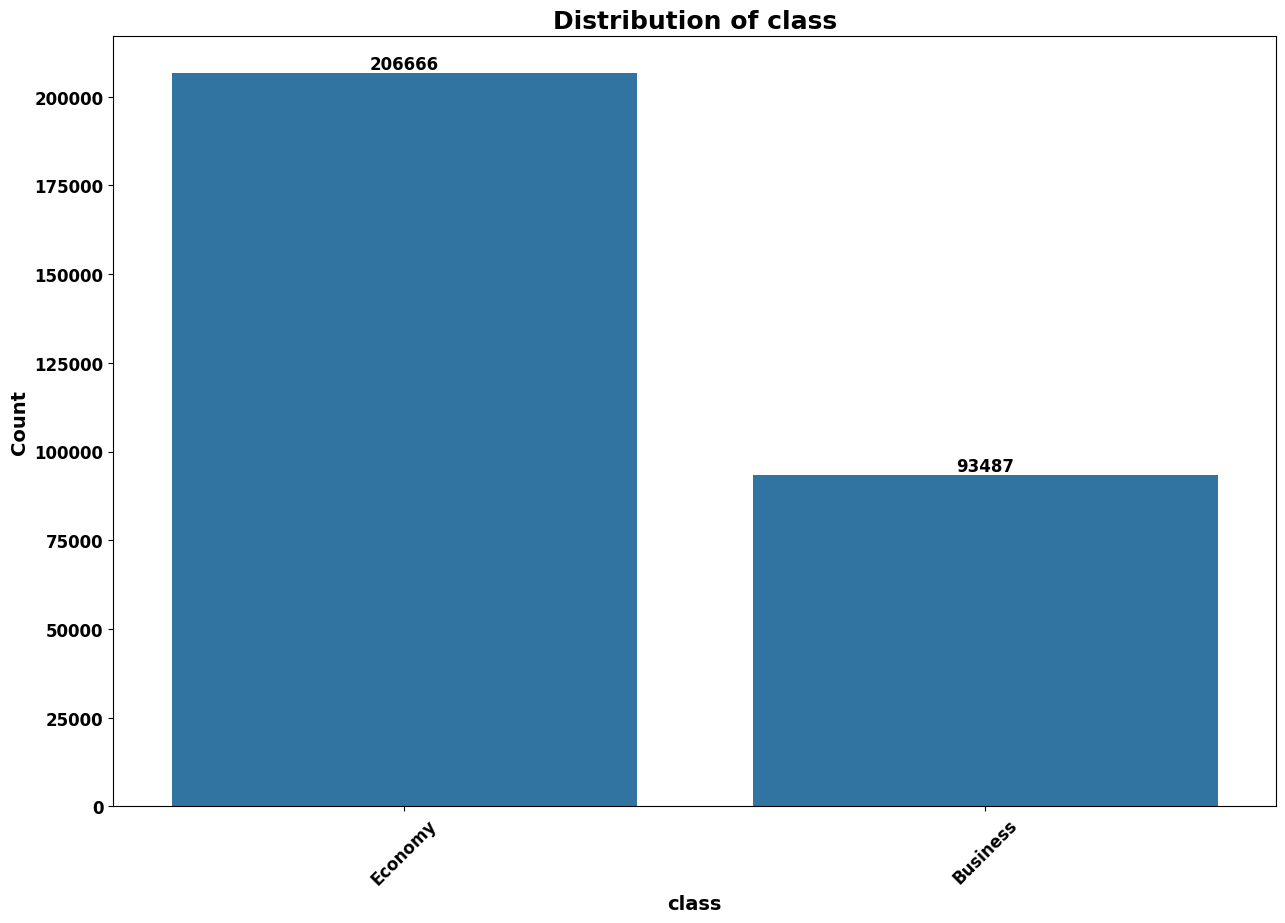

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(15, 10))

    # Sort categories by descending count
    order = df[col].value_counts().index

    ax = sns.countplot(data=df, x=col, order=order)

    # Add data labels with bold font
    for container in ax.containers:
        ax.bar_label(container, fontweight='bold', fontsize=12)

    # Bold title and axis labels
    plt.title(f'Distribution of {col}', fontsize=18, fontweight='bold')
    plt.xlabel(col, fontsize=14, fontweight='bold')
    plt.ylabel('Count', fontsize=14, fontweight='bold')

    # Bold x and y tick labels
    plt.xticks(rotation=45, fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')

    plt.show()

In [ ]:
# Top 10 flights


top_flights = (
    df.groupby(['flight', 'airline'])
      .size()
      .reset_index(name='count')
      .sort_values(by='count', ascending=False)
)

top_flights.head(10)

,flight,airline,count
1442,UK-706,Vistara,3235
1454,UK-772,Vistara,2741
1445,UK-720,Vistara,2650
1490,UK-836,Vistara,2542
1477,UK-822,Vistara,2468
1483,UK-828,Vistara,2440
1518,UK-874,Vistara,2423
1486,UK-832,Vistara,2404
1481,UK-826,Vistara,2335
1508,UK-860,Vistara,2329


In [ ]:
# Finding top 10 routes

top_routes = (
    df.groupby(['source_city', 'destination_city'])
      .size()
      .reset_index(name='count')
      .sort_values(by='count', ascending=False)
)

top_routes.head(10)

,source_city,destination_city,count
14,Delhi,Mumbai,15289
27,Mumbai,Delhi,14809
10,Delhi,Bangalore,14012
1,Bangalore,Delhi,13756
4,Bangalore,Mumbai,12939
25,Mumbai,Bangalore,12885
29,Mumbai,Kolkata,12602
13,Delhi,Kolkata,11934
24,Kolkata,Mumbai,11467
11,Delhi,Chennai,10780


In [ ]:
# Select only numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['duration', 'days_left', 'price'], dtype='object')

In [ ]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


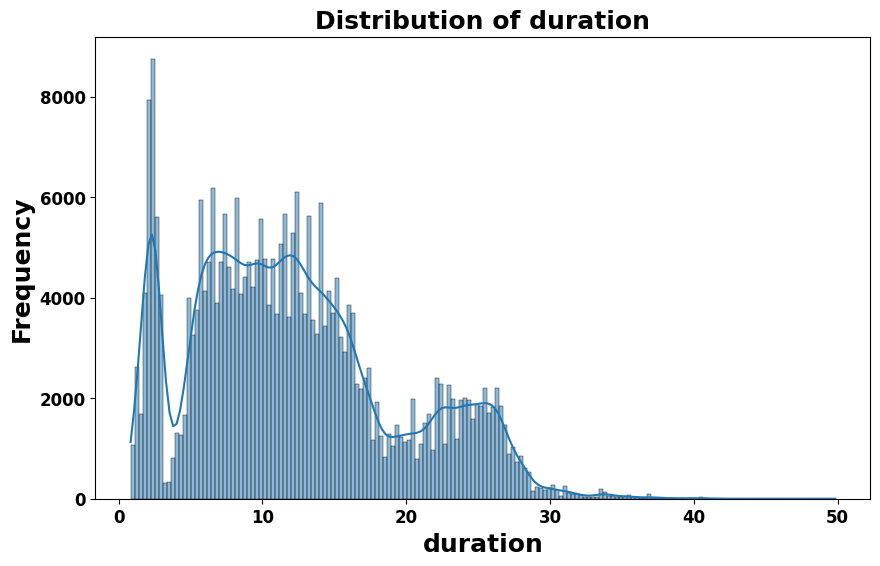

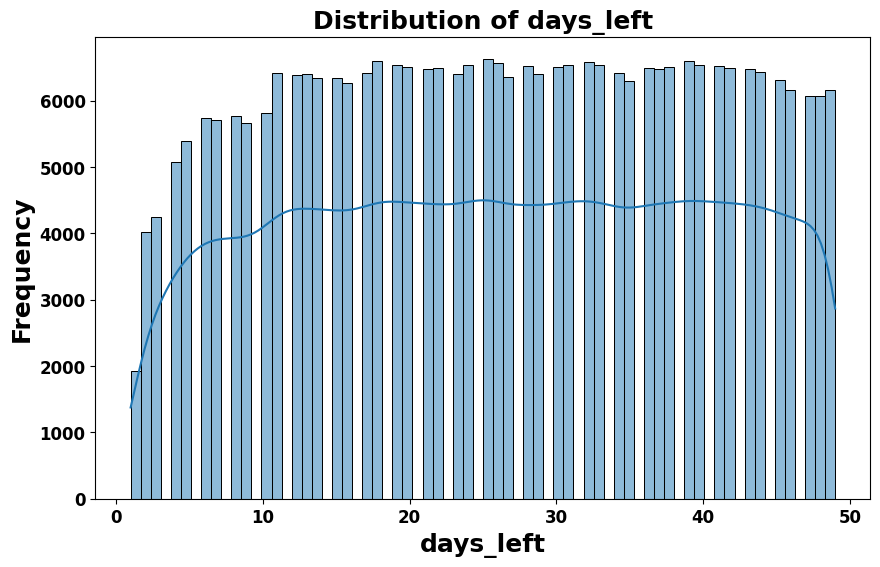

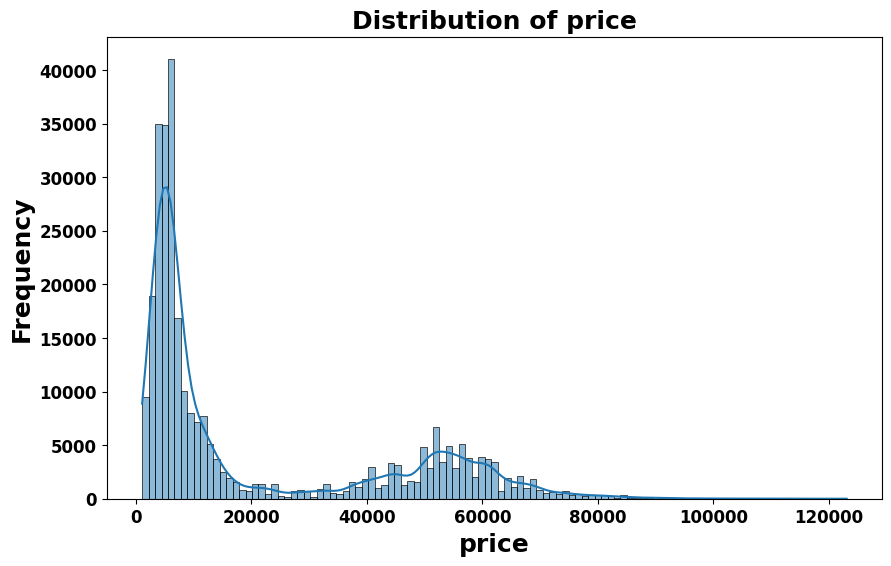

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10, 6))

    sns.histplot(df[col], kde=True)

    plt.title(f'Distribution of {col}', fontsize=18, fontweight='bold')
    plt.xlabel(col, fontsize=18, fontweight='bold')
    plt.ylabel('Frequency', fontsize=18, fontweight='bold')

    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')

    plt.show()

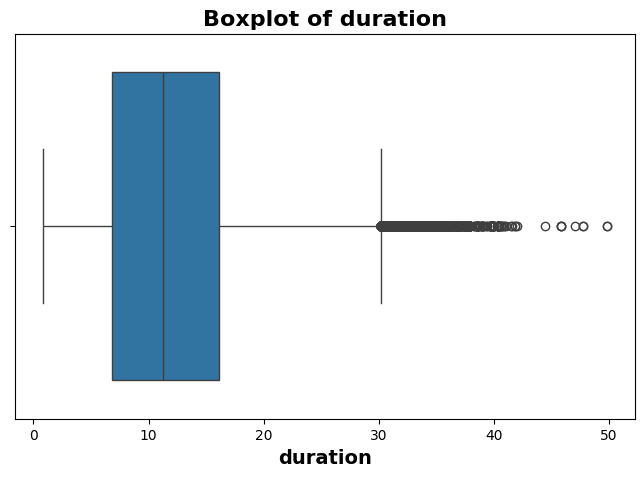

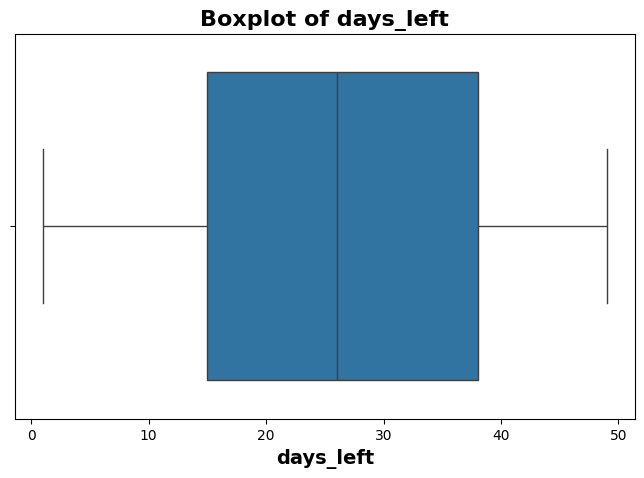

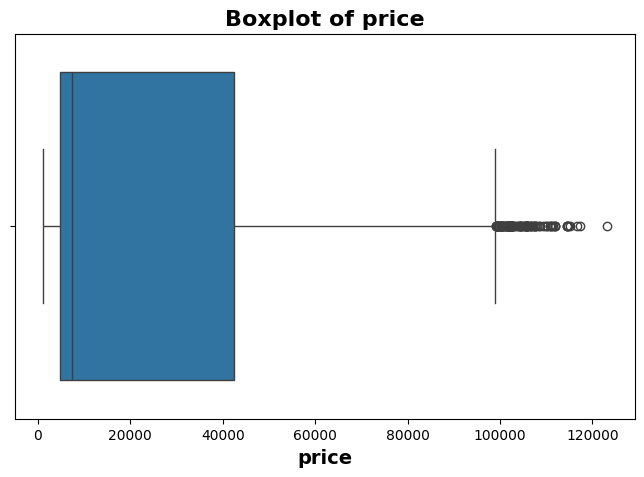

In [ ]:
# outliers detection
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}', fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=14, fontweight='bold')

    plt.show()

In [ ]:
# outlier detection using IQR method

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"{col}: {len(outliers)} outliers")

duration: 2110 outliers
days_left: 0 outliers
price: 123 outliers


In [ ]:
# Removing outliers

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    df = df.drop(outliers.index)

In [ ]:
# Rechecking outliers using IQR method

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"{col}: {len(outliers)} outliers")

duration: 226 outliers
days_left: 0 outliers
price: 0 outliers


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297921 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           297921 non-null  object 
 1   flight            297921 non-null  object 
 2   source_city       297921 non-null  object 
 3   departure_time    297921 non-null  object 
 4   stops             297921 non-null  object 
 5   arrival_time      297921 non-null  object 
 6   destination_city  297921 non-null  object 
 7   class             297921 non-null  object 
 8   duration          297921 non-null  float64
 9   days_left         297921 non-null  float64
 10  price             297921 non-null  float64
dtypes: float64(3), object(8)
memory usage: 27.3+ MB


300153 - 297921 = 2232 rows removed due to outliers

### Outlier Detection and Removal

Outliers in the numerical features (`duration`, `days_left`, and `price`) were identified and handled to ensure that extreme values do not disproportionately influence the model.

#### Method: Interquartile Range (IQR)

The Interquartile Range (IQR) method was employed to detect outliers. This method defines outliers as data points that fall below the first quartile (Q1) minus 1.5 times the IQR, or above the third quartile (Q3) plus 1.5 times the IQR.

-   **Q1 (First Quartile):** Represents the 25th percentile of the data.
-   **Q3 (Third Quartile):** Represents the 75th percentile of the data.
-   **IQR (Interquartile Range):** Calculated as `Q3 - Q1`.
-   **Lower Limit for Outliers:** `Q1 - (1.5 * IQR)`
-   **Upper Limit for Outliers:** `Q3 + (1.5 * IQR)`

Any data point outside these calculated lower and upper limits is considered an outlier.

#### Outlier Identification and Impact

Initially, the following outliers were detected:

-   `duration`: 2110 outliers
-   `days_left`: 0 outliers
-   `price`: 123 outliers

These outliers were subsequently removed from the dataset. This process led to the removal of `2232` rows, reducing the dataset from `300153` to `297921` entries. The reduction in the number of observations ensures that the statistical properties derived from the data are more robust and representative of the general trend, minimizing the skewing effect of extreme values.

After the initial removal, a re-check for outliers revealed:

-   `duration`: 226 outliers (some outliers might remain due to the iterative nature of IQR outlier detection or new distribution after removal)
-   `days_left`: 0 outliers
-   `price`: 0 outliers

The `price` column, which is the target variable, showed successful removal of all its identified outliers, contributing to a cleaner dataset for model training.

#### Bivariate Analysis

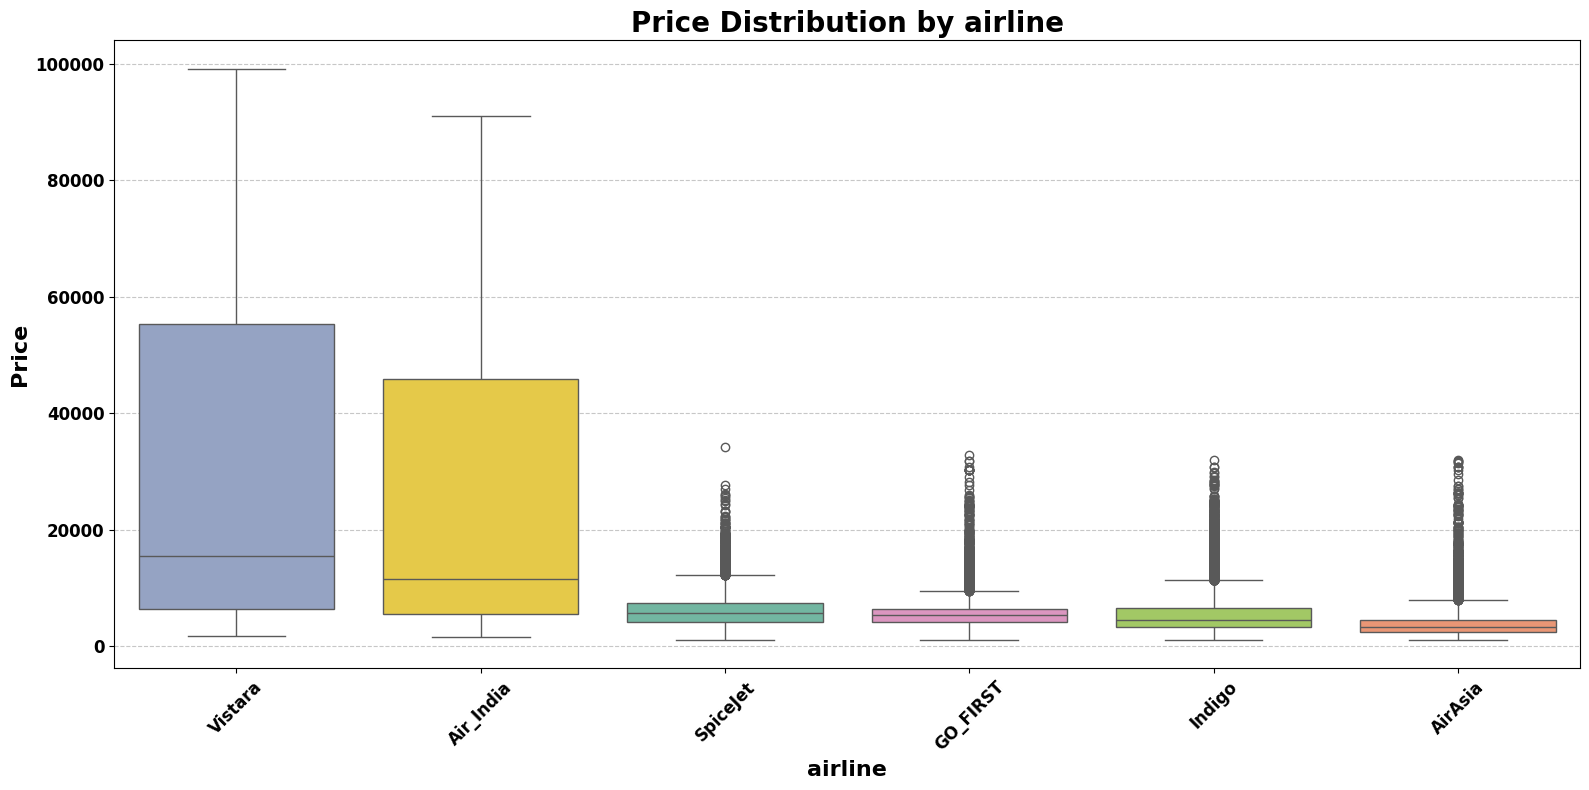

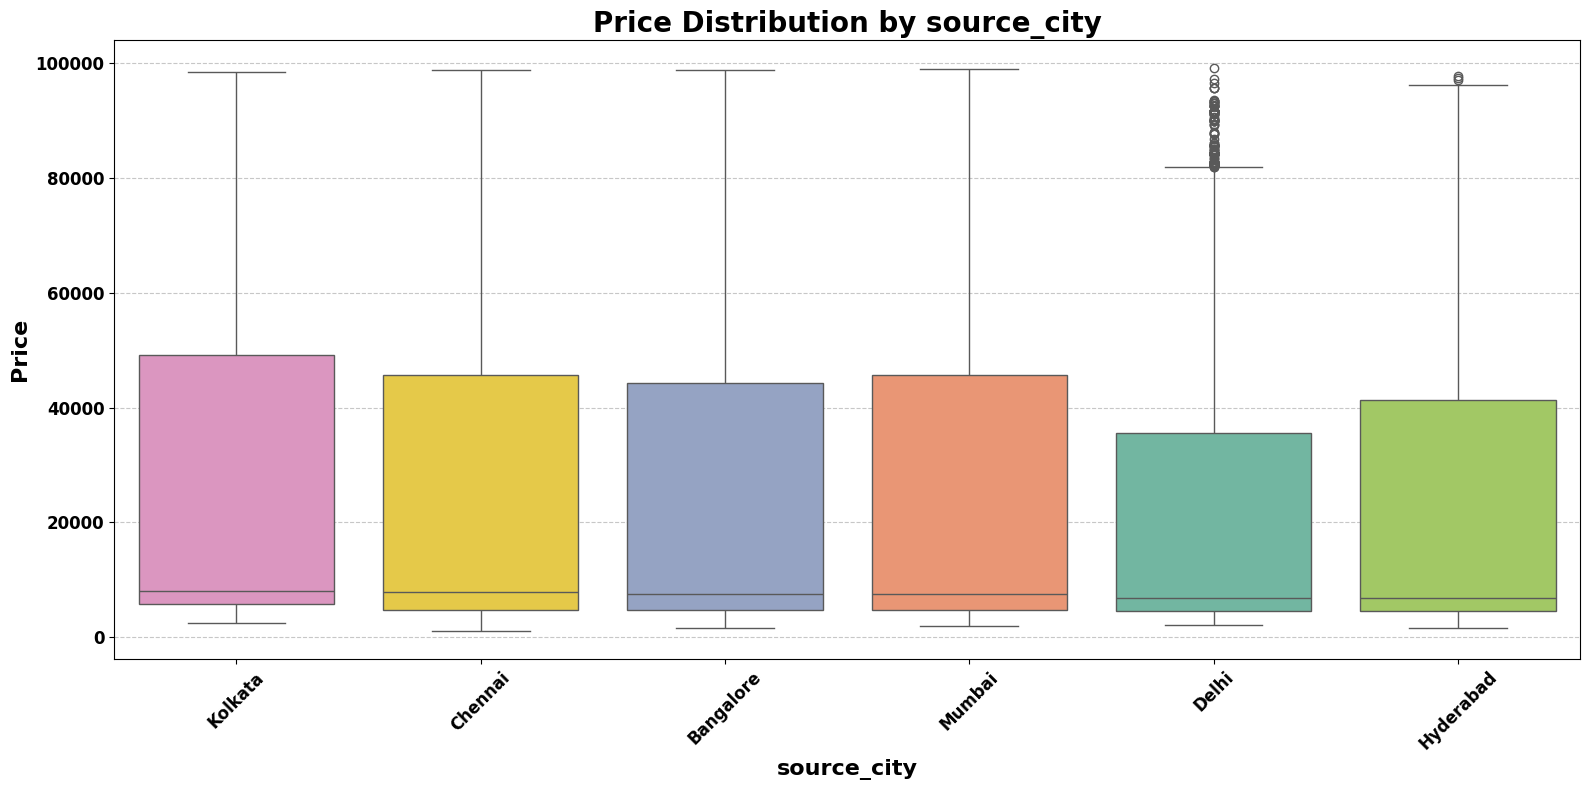

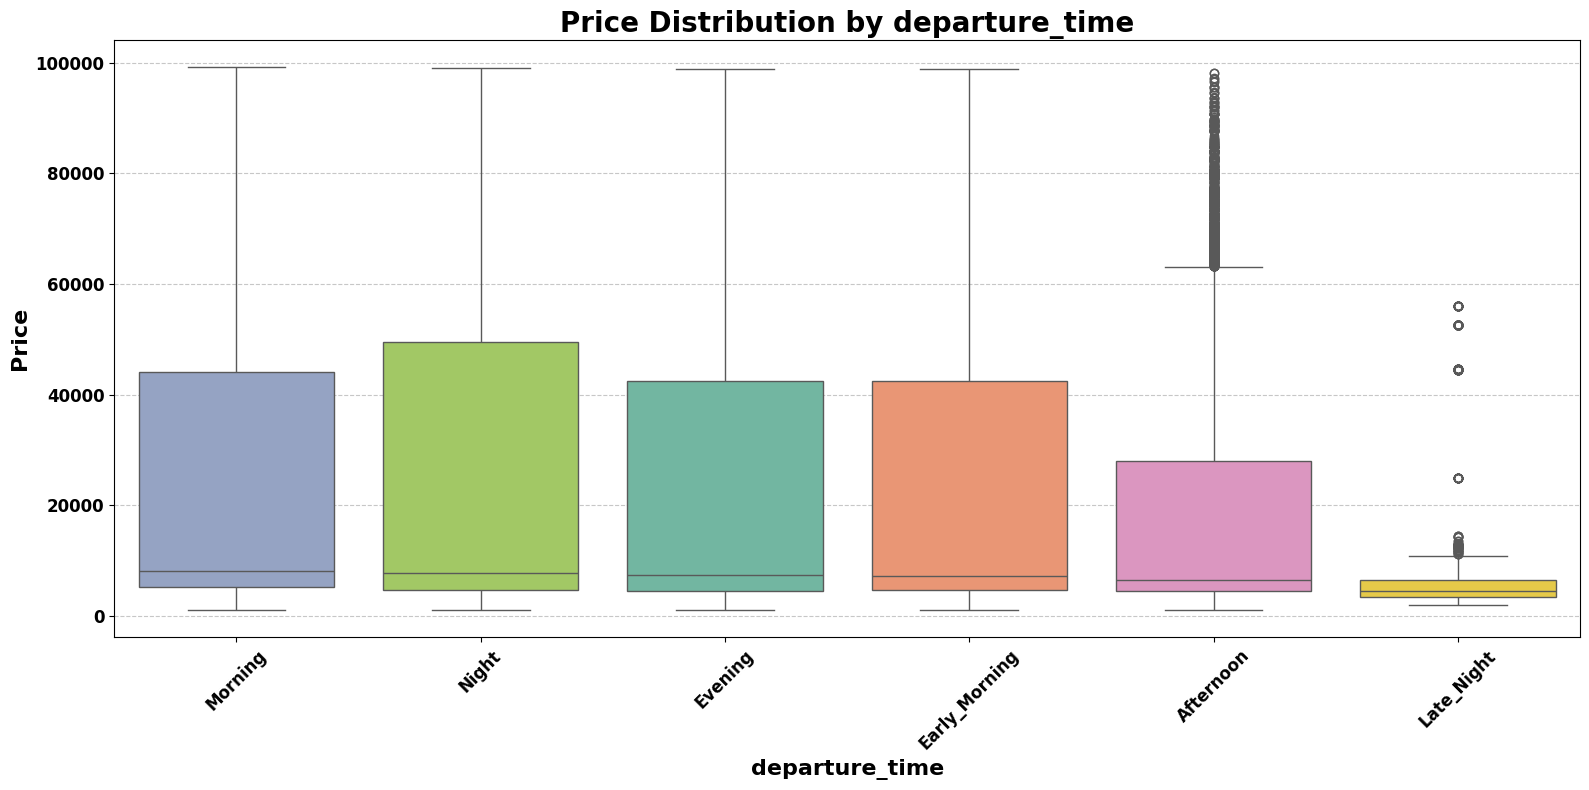

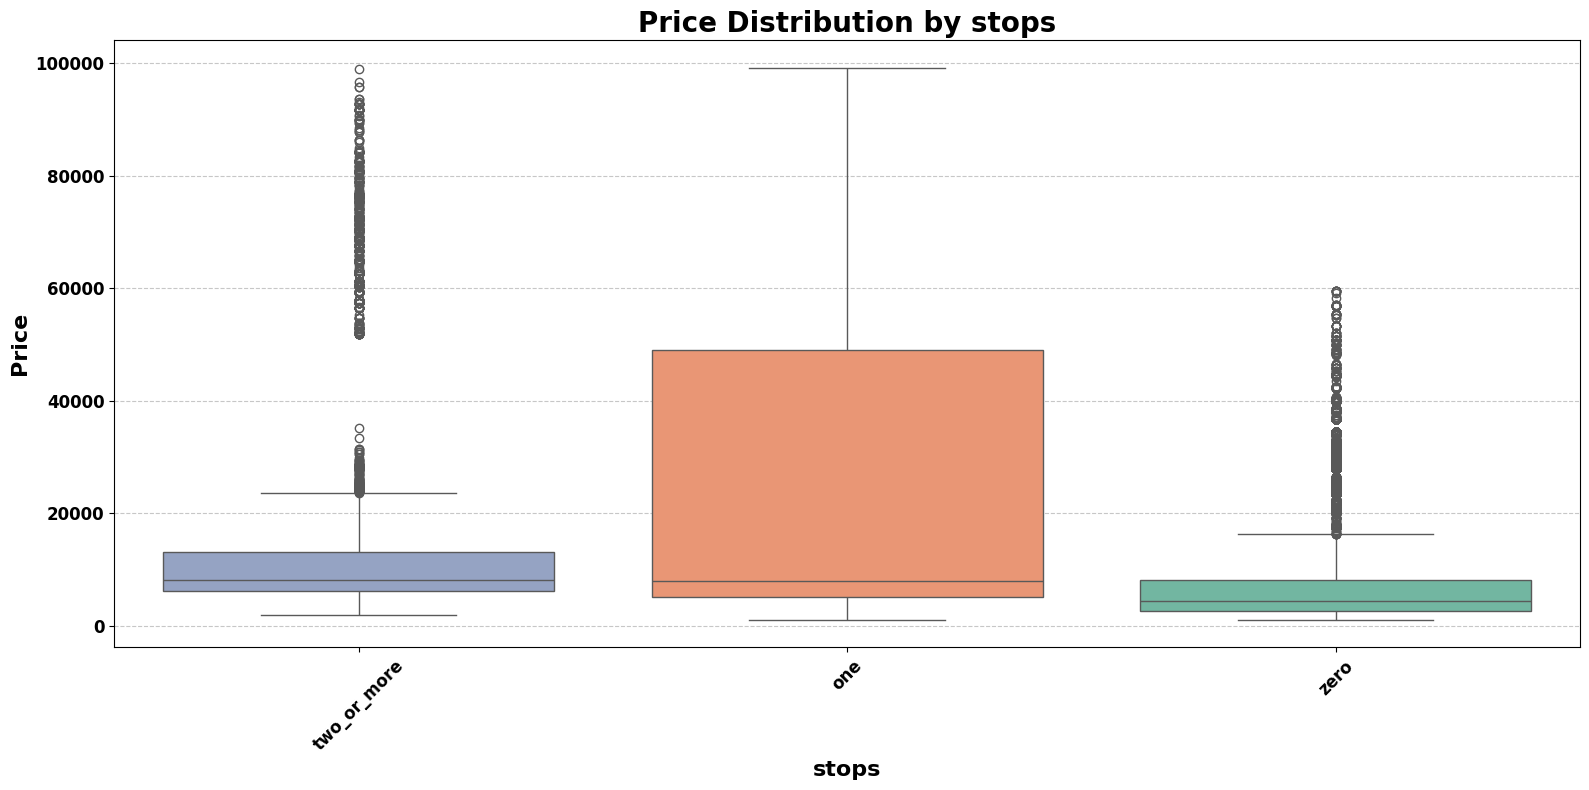

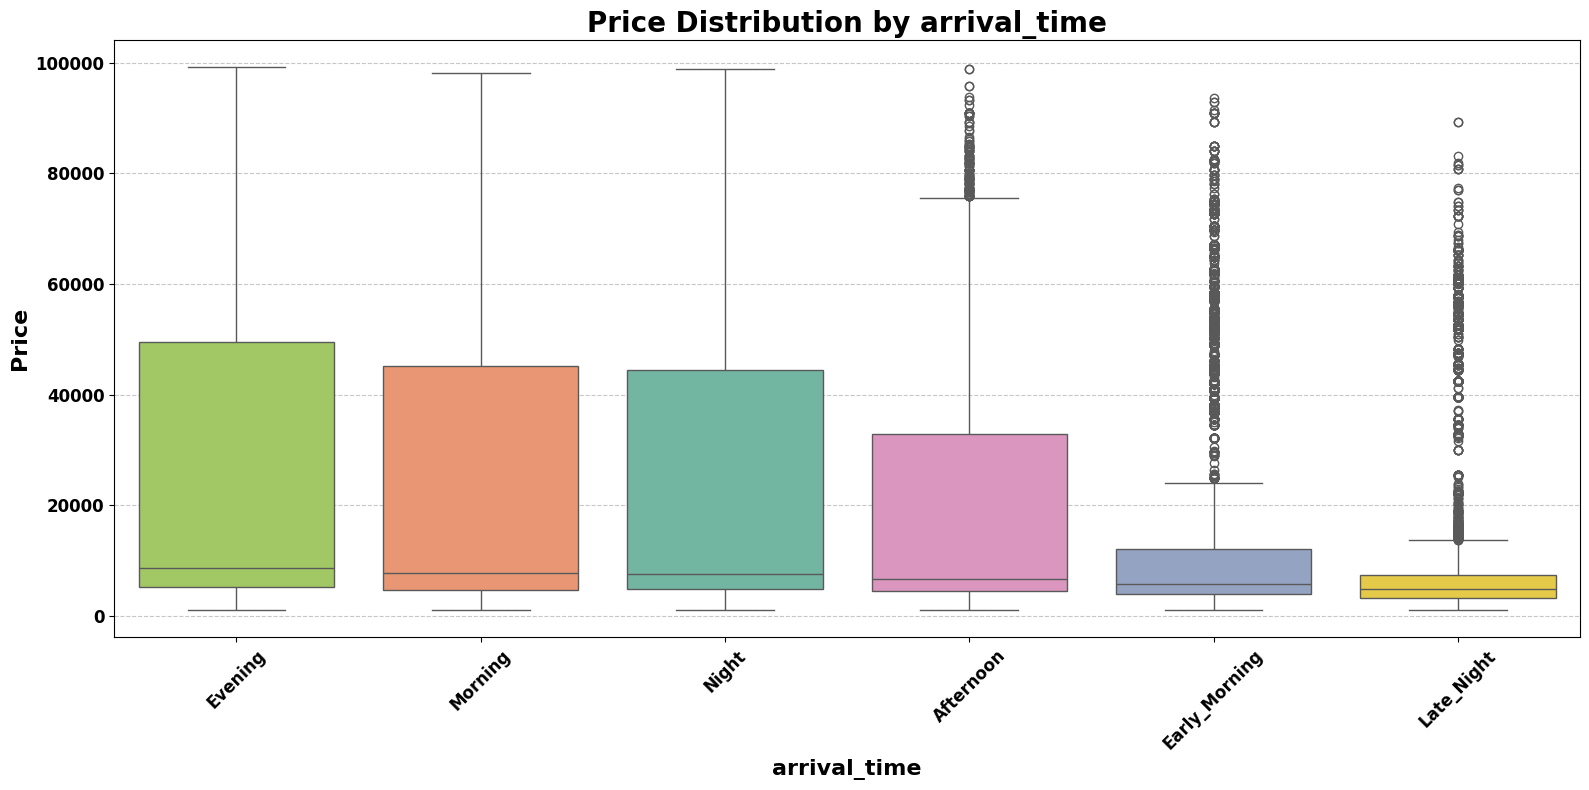

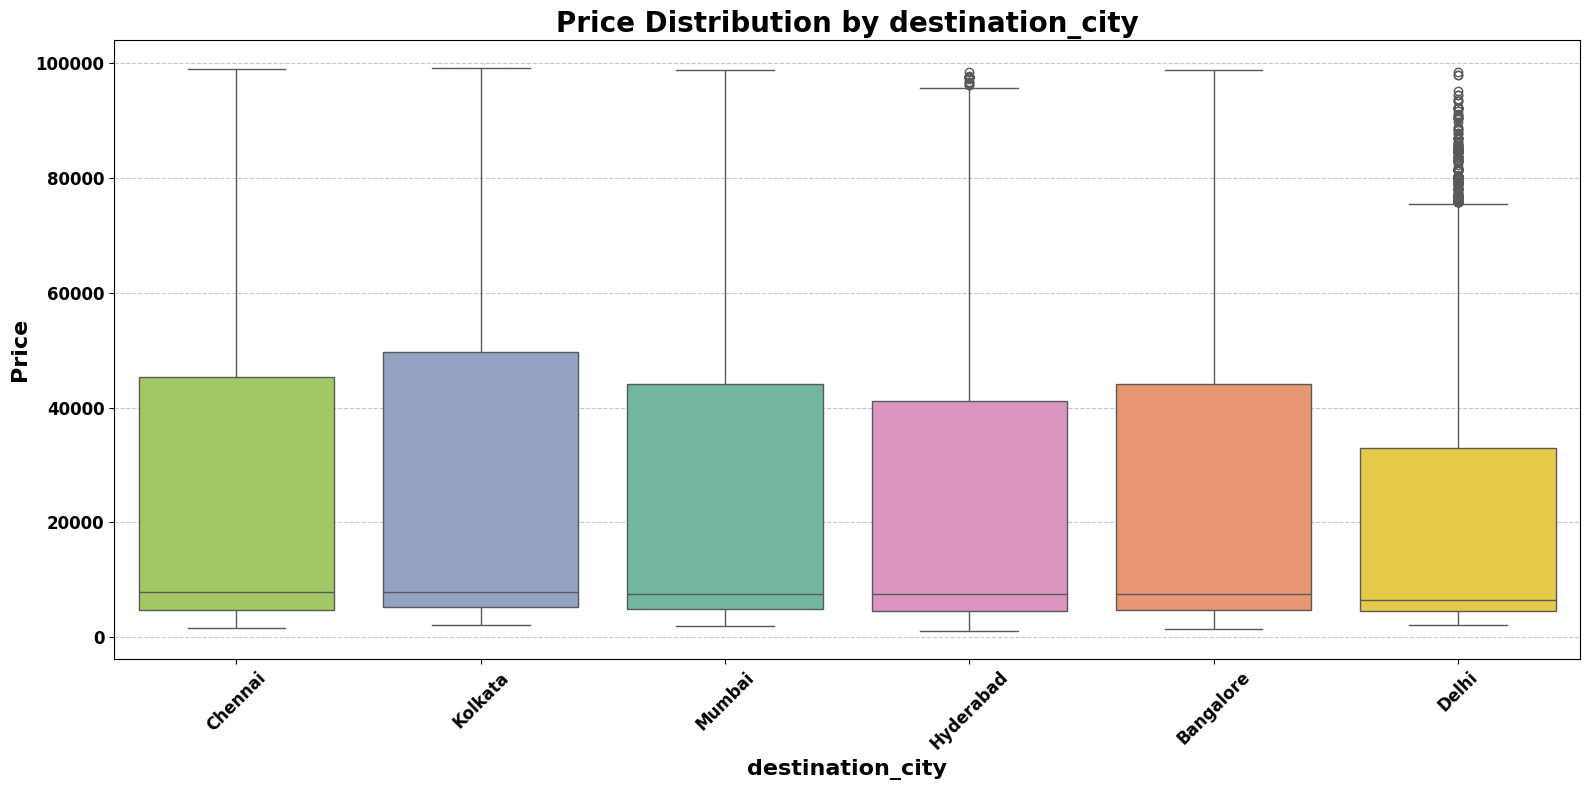

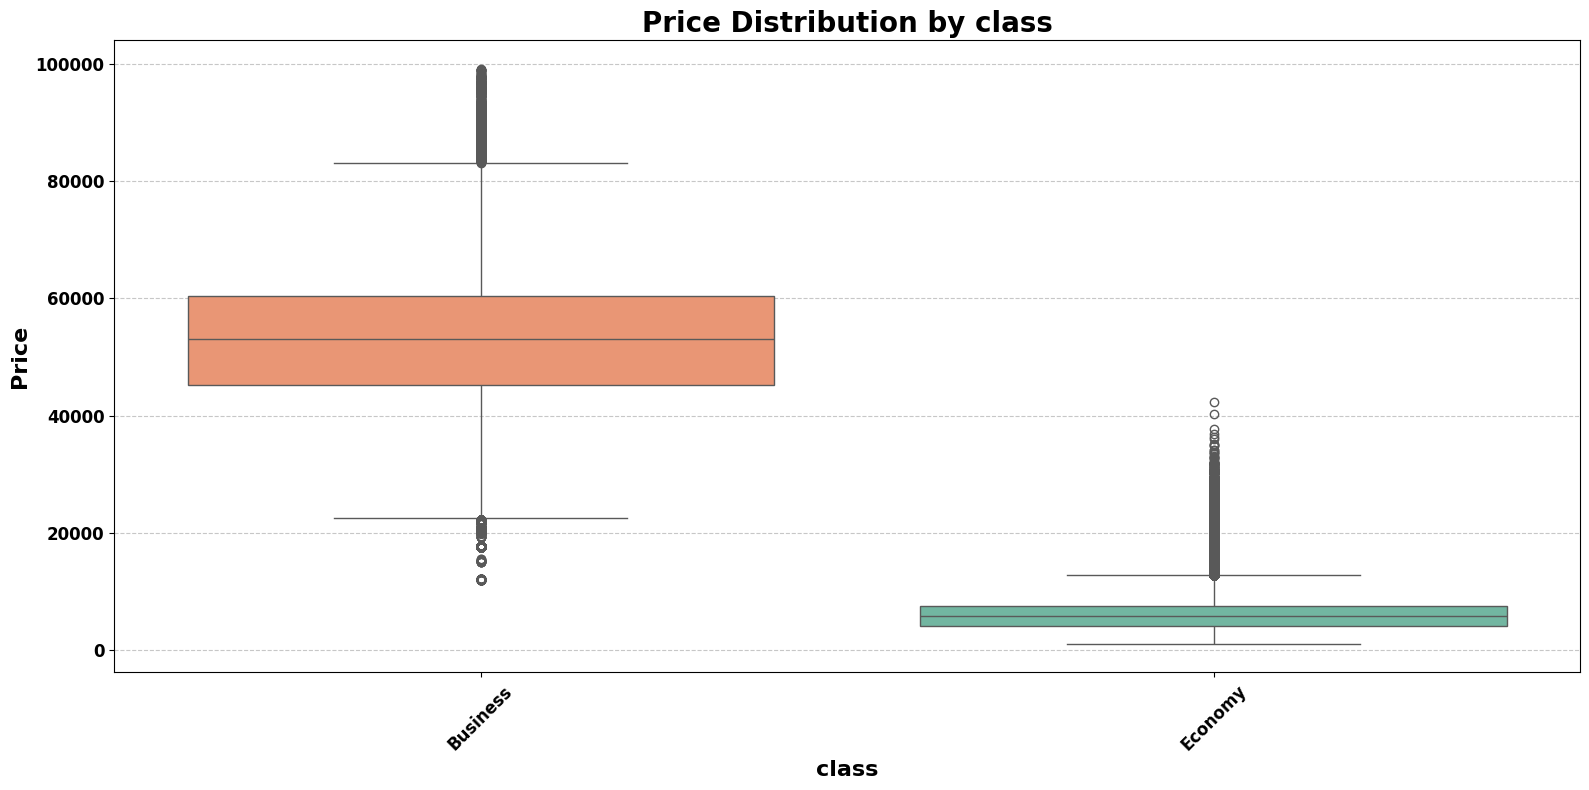

In [ ]:
reqcols = ['airline', 'source_city', 'departure_time', 'stops',
           'arrival_time', 'destination_city', 'class']

for col in reqcols:

    plt.figure(figsize=(16, 8))

    # Sort categories based on median price
    order = df.groupby(col)['price'].median().sort_values(ascending=False).index

    ax = sns.boxplot(
        data=df,
        x=col,
        y='price',
        hue=col,              # Added
        order=order,
        palette='Set2',
        legend=False          # Added
    )

    # Titles and labels
    plt.title(f'Price Distribution by {col}',
              fontsize=20,
              fontweight='bold')

    plt.xlabel(col,
               fontsize=16,
               fontweight='bold')

    plt.ylabel('Price',
               fontsize=16,
               fontweight='bold')

    # Tick styling
    plt.xticks(rotation=45,
               fontsize=12,
               fontweight='bold')

    plt.yticks(fontsize=12,
               fontweight='bold')

    # Grid for readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Tight layout
    plt.tight_layout()

    plt.show()

- Prices not affected much by source and destination columns. The effect of these is captured by duration. So, we can remove source and destination from the model.

- With departure and duration, we can find arrival time. So, it is redundant column. We can remove arrival time from the model.

- Also, flights we can remove. And take airlines in general.

- So final categorical columns - airline, departure_time, stops, class

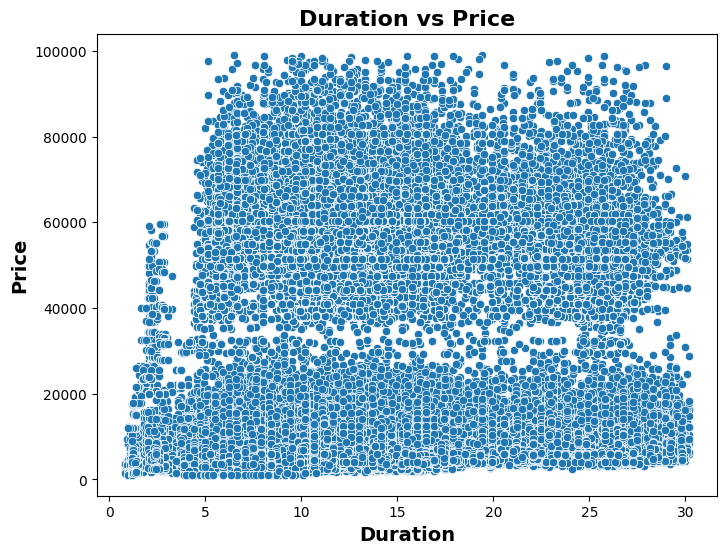

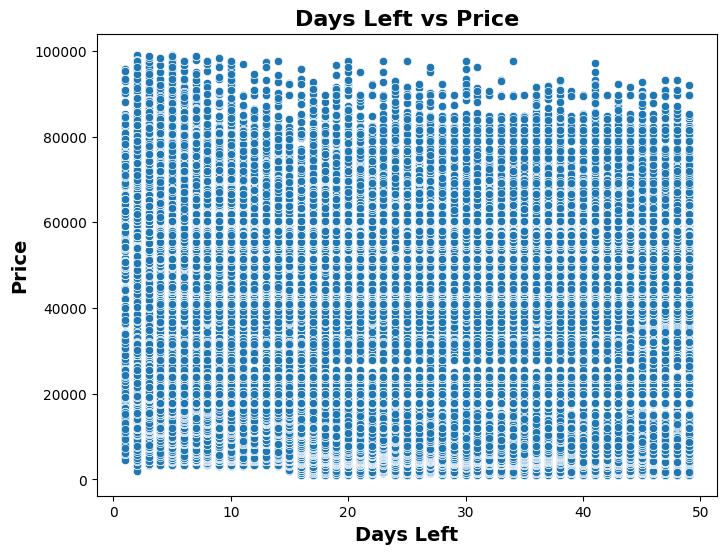

In [ ]:
# Numerical cols

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='duration', y='price')

plt.title('Duration vs Price', fontsize=16, fontweight='bold')
plt.xlabel('Duration', fontsize=14, fontweight='bold')
plt.ylabel('Price', fontsize=14, fontweight='bold')

plt.show()



plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='days_left', y='price')

plt.title('Days Left vs Price', fontsize=16, fontweight='bold')
plt.xlabel('Days Left', fontsize=14, fontweight='bold')
plt.ylabel('Price', fontsize=14, fontweight='bold')

plt.show()

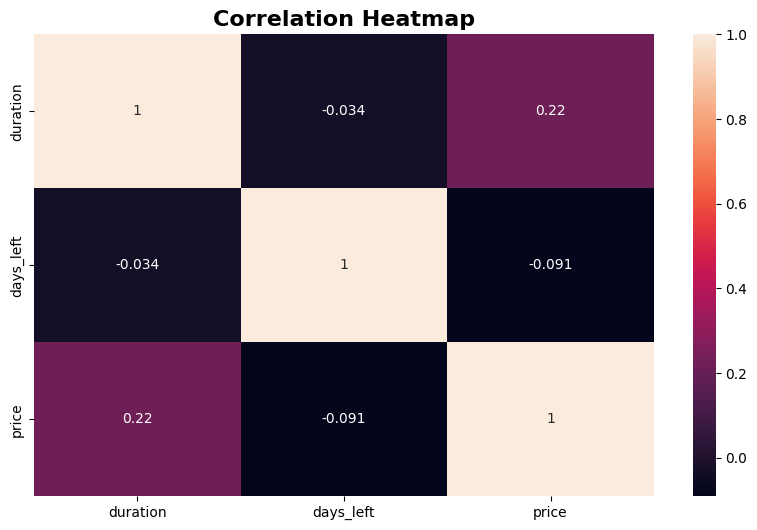

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df[num_cols].corr(), annot=True)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')

plt.show()

### Linear Regression


In [ ]:
pip install statsmodels

In [ ]:
# Import libraries
import pandas as pd
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Columns
cat_cols = ['airline', 'departure_time', 'stops', 'class']
num_cols = ['duration', 'days_left']

# Features and target
X = df[cat_cols + num_cols]
y = df['price']

# One-hot encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Convert all columns to float
X_encoded = X_encoded.astype(float)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Add constant to both train and test
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Build model
model = sm.OLS(y_train, X_train_sm).fit()

# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                 1.583e+05
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        13:27:46   Log-Likelihood:            -2.4430e+06
No. Observations:              238336   AIC:                         4.886e+06
Df Residuals:                  238320   BIC:                         4.886e+06
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test_sm)

# Evaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, y_pred))

MAE : 4589.19300237184
MSE : 46785249.22025117
RMSE: 6839.974358157432
R2 Score: 0.9093030427677785
